In [10]:
from IPython.display import HTML, display  # Imports notebook display helpers for adjusting the notebook width.
display(HTML("<style>.container { width:100% !important; }</style>"))  # Expands the notebook container so tables are easier to read.


# Lab | Natural Language Processing
### SMS: SPAM or HAM

### Let's prepare the environment

In [11]:
import html  # Imports HTML utilities so encoded entities such as &nbsp; can be decoded.
import re  # Imports regular expressions for cleaning email text patterns.
import string  # Imports punctuation characters used during text cleaning.
import pandas as pd  # Imports pandas for loading and manipulating tabular email data.
from pathlib import Path  # Imports Path so the dataset can be found from either the lab root or your-code folder.
import matplotlib.pyplot as plt  # Imports pyplot for exploratory charts.
import nltk  # Imports NLTK for stopwords, tokenization, and lemmatization.
from nltk.corpus import stopwords  # Imports the English stopword list from NLTK.
from nltk.stem import WordNetLemmatizer  # Imports the WordNet lemmatizer for reducing words to base forms.
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer  # Imports vectorizers for Bag of Words and TF-IDF features.
from sklearn.metrics import accuracy_score, classification_report  # Imports metrics for evaluating the spam classifier.
from sklearn.model_selection import train_test_split  # Imports a helper for splitting data into train and test sets.
from sklearn.naive_bayes import MultinomialNB  # Imports a fast classical Naive Bayes classifier for text classification.
nltk.download("punkt", quiet=True)  # Downloads the tokenizer data if it is not already available.
nltk.download("punkt_tab", quiet=True)  # Downloads newer tokenizer table data if the installed NLTK expects it.
nltk.download("stopwords", quiet=True)  # Downloads the English stopword list if it is not already available.
nltk.download("wordnet", quiet=True)  # Downloads WordNet data for lemmatization if it is not already available.
nltk.download("omw-1.4", quiet=True)  # Downloads WordNet multilingual mappings used by recent NLTK versions.


True

- Read Data for the Fraudulent Email Kaggle Challenge
- Reduce the training set to speead up development. 

In [12]:
candidate_data_paths = [Path("data/kg_train.csv"), Path("../data/kg_train.csv")]  # Lists the possible dataset paths from the lab root and your-code folder.
data_path = next(path for path in candidate_data_paths if path.exists())  # Selects the first dataset path that exists on this machine.
data = pd.read_csv(data_path, encoding="latin-1")  # Reads the labeled training emails from the resolved CSV file.
data = data.head(1000).copy()  # Keeps the first 1000 rows so development stays fast on a local machine.
print(data.shape)  # Confirms the current array or table dimensions.
data.fillna("", inplace=True)  # Replaces missing text values with empty strings to avoid cleaning errors later.
data.head()  # Provides a compact notebook preview for review.


(1000, 2)


,text,label
0,"DEAR SIR, STRICTLY A PRIVATE BUSINESS PROPOSAL...",1
1,Will do.,0
2,Nora--Cheryl has emailed dozens of memos about...,0
3,Dear Sir=2FMadam=2C I know that this proposal ...,1
4,fyi,0


### Let's divide the training and test set into two partitions

In [13]:
X = data["text"]  # Stores the email text column as the model input.
y = data["label"]  # Stores the spam/ham label column as the model target.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)  # Splits the data into reproducible train and test partitions.
print(X_train.shape, X_test.shape)# Confirms the current array or table dimensions.
print(y_train.value_counts(normalize=True))# Reviews the label distribution for the dataset.


(800,) (200,)
label
0    0.5575
1    0.4425
Name: proportion, dtype: float64


## Data Preprocessing

In [14]:
print(string.punctuation)# Reviews punctuation characters targeted during cleaning.
english_stopwords = set(stopwords.words("english"))  # Stores English stopwords in a set for fast lookup.
print(list(english_stopwords)[100:110])# Reviews a sample of stopwords used during cleaning.
lemmatizer = WordNetLemmatizer()  # Creates a lemmatizer that will reduce words to their dictionary form.


!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
['d', 'ours', 'couldn', 'with', 'won', 'am', "shan't", 'when', 'does', 'had']


## Now, we have to clean the html code removing words

- First we remove inline JavaScript/CSS
- Then we remove html comments. This has to be done before removing regular tags since comments can contain '>' characters
- Next we can remove the remaining tags

In [15]:
def remove_html(raw_text):  # Defines a helper function for removing HTML, JavaScript, CSS, and comments.
    text_without_scripts = re.sub(r"<script.*?>.*?</script>", " ", raw_text, flags=re.IGNORECASE | re.DOTALL)  # Removes inline JavaScript blocks.
    text_without_styles = re.sub(r"<style.*?>.*?</style>", " ", text_without_scripts, flags=re.IGNORECASE | re.DOTALL)  # Removes inline CSS blocks.
    text_without_comments = re.sub(r"<!--.*?-->", " ", text_without_styles, flags=re.DOTALL)  # Removes HTML comments before regular tags.
    text_without_tags = re.sub(r"<[^>]+>", " ", text_without_comments)  # Removes remaining HTML tags.
    decoded_text = html.unescape(text_without_tags)  # Decodes HTML entities such as &amp; and &nbsp;.
    return decoded_text  # Returns the cleaned text with HTML markup removed.

data["text_no_html"] = data["text"].apply(remove_html)  # Applies the HTML cleaning helper to every email.
data[["text", "text_no_html"]].head()# Provides a compact notebook preview for review.


,text,text_no_html
0,"DEAR SIR, STRICTLY A PRIVATE BUSINESS PROPOSAL...","DEAR SIR, STRICTLY A PRIVATE BUSINESS PROPOSAL..."
1,Will do.,Will do.
2,Nora--Cheryl has emailed dozens of memos about...,Nora--Cheryl has emailed dozens of memos about...
3,Dear Sir=2FMadam=2C I know that this proposal ...,Dear Sir=2FMadam=2C I know that this proposal ...
4,fyi,fyi


- Remove all the special characters
    
- Remove numbers
    
- Remove all single characters
 
- Remove single characters from the start

- Substitute multiple spaces with single space

- Remove prefixed 'b'

- Convert to Lowercase

In [16]:
def normalize_text(raw_text):  # Defines a helper that performs general text normalization.
    text_without_html = remove_html(raw_text)  # Removes HTML markup before other text cleanup steps.
    text_without_specials = re.sub(r"[^a-zA-Z]", " ", text_without_html)  # Keeps letters only and replaces everything else with spaces.
    text_without_single_letters = re.sub(r"\b[a-zA-Z]\b", " ", text_without_specials)  # Removes isolated one-letter tokens.
    text_without_prefixed_b = re.sub(r"^b\s+", " ", text_without_single_letters)  # Removes a leading byte-string marker if one appears.
    text_with_single_spaces = re.sub(r"\s+", " ", text_without_prefixed_b)  # Collapses repeated whitespace into single spaces.
    lowercase_text = text_with_single_spaces.lower().strip()  # Converts the text to lowercase and removes edge spaces.
    return lowercase_text  # Returns the normalized text.

data["clean_text"] = data["text"].apply(normalize_text)  # Creates a normalized text column for the whole dataset.
X_train_clean = X_train.apply(normalize_text)  # Cleans the training text split using the same function.
X_test_clean = X_test.apply(normalize_text)  # Cleans the test text split using the same function.
data[["text", "clean_text"]].head()# Provides a compact notebook preview for review.


,text,clean_text
0,"DEAR SIR, STRICTLY A PRIVATE BUSINESS PROPOSAL...",dear sir strictly private business proposal am...
1,Will do.,will do
2,Nora--Cheryl has emailed dozens of memos about...,nora cheryl has emailed dozens of memos about ...
3,Dear Sir=2FMadam=2C I know that this proposal ...,dear sir fmadam know that this proposal might ...
4,fyi,fyi


## Now let's work on removing stopwords
Remove the stopwords.

In [17]:
def remove_stopwords(clean_text):  # Defines a helper that removes common English stopwords.
    tokens = clean_text.split()  # Splits each cleaned message into word tokens.
    useful_tokens = [token for token in tokens if token not in english_stopwords]  # Keeps only tokens that are not stopwords.
    return " ".join(useful_tokens)  # Joins the remaining tokens back into one cleaned string.

data["text_no_stopwords"] = data["clean_text"].apply(remove_stopwords)  # Removes stopwords from the full cleaned dataset.
X_train_no_stopwords = X_train_clean.apply(remove_stopwords)  # Removes stopwords from the cleaned training split.
X_test_no_stopwords = X_test_clean.apply(remove_stopwords)  # Removes stopwords from the cleaned test split.
data[["clean_text", "text_no_stopwords"]].head()# Provides a compact notebook preview for review.


,clean_text,text_no_stopwords
0,dear sir strictly private business proposal am...,dear sir strictly private business proposal mi...
1,will do,
2,nora cheryl has emailed dozens of memos about ...,nora cheryl emailed dozens memos haiti weekend...
3,dear sir fmadam know that this proposal might ...,dear sir fmadam know proposal might surprise e...
4,fyi,fyi


## Tame Your Text with Lemmatization
Break sentences into words, then use lemmatization to reduce them to their base form (e.g., "running" becomes "run"). See how this creates cleaner data for analysis!

In [18]:
def lemmatize_text(clean_text):  # Defines a helper that lemmatizes each token in a cleaned message.
    tokens = clean_text.split()  # Splits the cleaned message into tokens.
    lemmas = [lemmatizer.lemmatize(token) for token in tokens]  # Converts each token to its base WordNet form.
    return " ".join(lemmas)  # Joins the lemmatized tokens back into one string.

data["lemmatized_text"] = data["text_no_stopwords"].apply(lemmatize_text)  # Lemmatizes the no-stopword text for the full dataset.
X_train_final = X_train_no_stopwords.apply(lemmatize_text)  # Lemmatizes the training split for modeling.
X_test_final = X_test_no_stopwords.apply(lemmatize_text)  # Lemmatizes the test split for modeling.
data[["text_no_stopwords", "lemmatized_text"]].head()# Provides a compact notebook preview for review.


,text_no_stopwords,lemmatized_text
0,dear sir strictly private business proposal mi...,dear sir strictly private business proposal mi...
1,,
2,nora cheryl emailed dozens memos haiti weekend...,nora cheryl emailed dozen memo haiti weekend p...
3,dear sir fmadam know proposal might surprise e...,dear sir fmadam know proposal might surprise e...
4,fyi,fyi


## Bag Of Words
Let's get the 10 top words in ham and spam messages (**EXPLORATORY DATA ANALYSIS**)

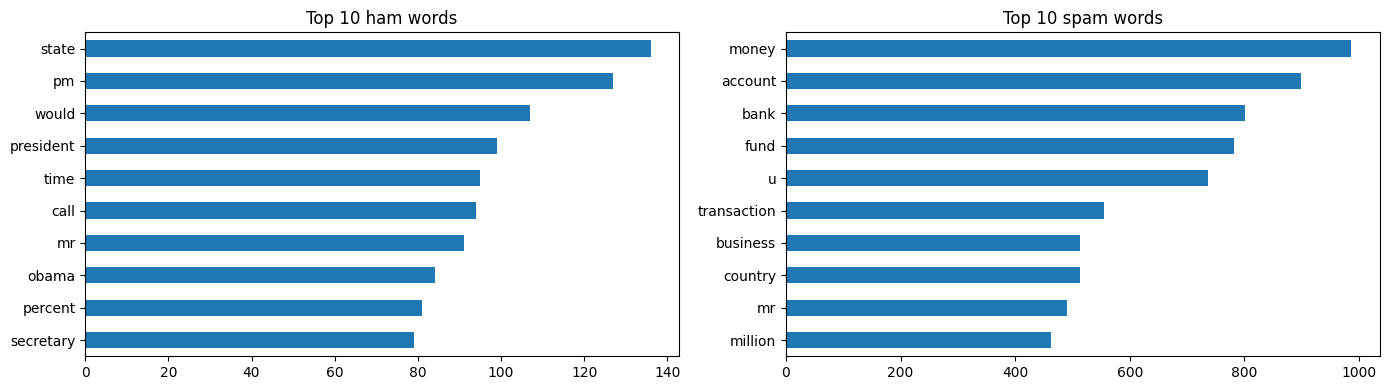

Top ham words:
state        136
pm           127
would        107
president     99
time          95
call          94
mr            91
obama         84
percent       81
secretary     79
Name: count, dtype: int64
Top spam words:
money          987
account        899
bank           801
fund           782
u              737
transaction    555
business       514
country        513
mr             490
million        463
Name: count, dtype: int64


In [19]:
ham_text = " ".join(data.loc[data["label"] == 0, "lemmatized_text"])  # Combines all ham messages into one large string.
spam_text = " ".join(data.loc[data["label"] == 1, "lemmatized_text"])  # Combines all spam messages into one large string.
ham_words = pd.Series(ham_text.split()).value_counts().head(10)  # Counts the 10 most common words in ham messages.
spam_words = pd.Series(spam_text.split()).value_counts().head(10)  # Counts the 10 most common words in spam messages.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))  # Creates two side-by-side bar charts for ham and spam words.
ham_words.sort_values().plot(kind="barh", ax=axes[0], title="Top 10 ham words")  # Plots the top ham words horizontally.
spam_words.sort_values().plot(kind="barh", ax=axes[1], title="Top 10 spam words")  # Plots the top spam words horizontally.
plt.tight_layout()  # Adjusts chart spacing so labels do not overlap.
plt.show()  # Renders the exploratory word-frequency charts.
print("Top ham words:")# Labels the following ham word-frequency table.
print(ham_words)# Reports the word-frequency counts as a table.
print("Top spam words:")# Labels the following spam word-frequency table.
print(spam_words)# Reports the word-frequency counts as a table.


## Extra features

In [20]:
money_symbol_list = "|".join(["euro", "dollar", "pound", "?", r"\$"])  # Builds a regex pattern for money-related terms and symbols.
suspicious_words = "|".join(["free", "cheap", "sex", "money", "account", "bank", "fund", "transfer", "transaction", "win", "deposit", "password"])  # Builds a regex pattern for common spam-like words.
data["has_money_symbol"] = data["text"].str.contains(money_symbol_list, case=False, regex=True).astype(int)  # Marks messages that mention money terms or symbols.
data["has_suspicious_word"] = data["text"].str.contains(suspicious_words, case=False, regex=True).astype(int)  # Marks messages that contain suspicious words.
data[["has_money_symbol", "has_suspicious_word", "label"]].head()# Provides a compact notebook preview for review.


error: nothing to repeat at position 18

## How would you create a Bag of Words with the CountVectorizer method?

In [ ]:
count_vectorizer = CountVectorizer(max_features=1000)  # Creates a Bag of Words vectorizer limited to the 1000 most frequent terms.
bow_matrix = count_vectorizer.fit_transform(data["lemmatized_text"])  # Learns the vocabulary and transforms all messages into count vectors.
bow_feature_names = count_vectorizer.get_feature_names_out()  # Stores the learned vocabulary terms in order.
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_feature_names)  # Converts the sparse Bag of Words matrix to a readable DataFrame.
print(bow_df.shape)# Confirms the current array or table dimensions.
bow_df.head()# Provides a compact notebook preview for review.


## TF-IDF

- Load the vectorizer

- Vectorize all dataset

- print the shape of the vetorized dataset

In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # Creates a TF-IDF vectorizer limited to the 1000 most important terms.
tfidf_matrix = tfidf_vectorizer.fit_transform(data["lemmatized_text"])  # Learns TF-IDF weights and transforms all messages.
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()  # Stores the learned TF-IDF feature names.
print(tfidf_matrix.shape)# Confirms the current array or table dimensions.
pd.DataFrame(tfidf_matrix[:5].toarray(), columns=tfidf_feature_names).head()# Provides a compact notebook preview for review.


### Extra Task (optional) - Implement a SPAM/HAM classifier

https://www.kaggle.com/t/b384e34013d54d238490103bc3c360ce

Use a MultinimialNB with default parameters.

Your task is to **find the most relevant features**.

For example, you can test the following options and check which of them performs better:
- Using "Bag of Words" only
- Using "TF-IDF" only
- Bag of Words + extra flags (money_mark, suspicious_words, text_len)
- TF-IDF + extra flags


You can work with teams of two persons (recommended).

In [21]:
model_vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))  # Creates TF-IDF features using unigrams and bigrams for the classifier.
X_train_vectors = model_vectorizer.fit_transform(X_train_final)  # Fits the vectorizer on training text and transforms the training split.
X_test_vectors = model_vectorizer.transform(X_test_final)  # Transforms the test split with the training vocabulary only.
spam_classifier = MultinomialNB()  # Creates a Multinomial Naive Bayes classifier suitable for text features.
spam_classifier.fit(X_train_vectors, y_train)  # Trains the classifier on the local TF-IDF training matrix.
y_pred = spam_classifier.predict(X_test_vectors)  # Predicts spam/ham labels for the held-out test set.
accuracy = accuracy_score(y_test, y_pred)  # Calculates the overall test accuracy.
print(f"Accuracy: {accuracy:.3f}")# Reports the accuracy metric for evaluation.
print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))# Reports precision, recall, F1 score, and support.
feature_names = model_vectorizer.get_feature_names_out()  # Retrieves the model feature names in the same order as the learned probabilities.
spam_log_probabilities = spam_classifier.feature_log_prob_[1]  # Gets log probabilities for features in the spam class.
top_spam_indices = spam_log_probabilities.argsort()[-20:][::-1]  # Finds the indices of the 20 strongest spam-indicative features.
top_spam_features = pd.DataFrame({"feature": feature_names[top_spam_indices], "log_probability": spam_log_probabilities[top_spam_indices]})  # Builds a table of the strongest spam features.
top_spam_features# Reports this intermediate result for review.


Accuracy: 0.985
              precision    recall  f1-score   support

         ham       1.00      0.97      0.99       112
        spam       0.97      1.00      0.98        88

    accuracy                           0.98       200
   macro avg       0.98      0.99      0.98       200
weighted avg       0.99      0.98      0.99       200



,feature,log_probability
0,money,-5.627433
1,account,-5.681021
2,bank,-5.702334
3,fund,-5.764990
4,transaction,-6.034811
5,mr,-6.059441
6,country,-6.091680
7,business,-6.106371
8,company,-6.152626
9,transfer,-6.236018
